# **EDA Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [1]:
# Do not modify this code
import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Mounted at /content/gdrive

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [3]:
# <Student to fill this section>
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta
import pickle
from IPython.display import display

import missingno as msno

### 0.d Import Packages

In [4]:
# <Student to fill this section>
import pandas as pd
import altair as alt

---
## A. Project Description


In [5]:
# <Student to fill this section>
group_name = "Group 18"
student_name = "Vonny Yudianto"
student_id = "25741719"

In [6]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [8]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Data Understanding

### B.1   Load Dataset

In [9]:
# Do not modify this code
try:
  df = pd.read_csv(folder_path / "customer_details.csv")
except Exception as e:
  print(e)

In [93]:
try:
  df1 = pd.read_csv(folder_path / "customer_usage.csv")
except Exception as e:
  print(e)

### B.2 Explore Dataset

> You can add more cells in this section

In [14]:
# <Student to fill this section>
df.head()

,Unnamed: 0,customer_id,full_name,gender,dob,age,is_young_adult,is_senior,birth_country,passport_number,...,city,postcode,state_abbr,address,cc_number,cc_expiry,cc_security_code,company_name,company_suffix,user_agent
0,0,9acb3a1e-a040-4280-887b-ef33381c7a16,Alexa Chung,Female,1974-10-10,50,No,No,AU,131053534,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,45360147-4c3e-4f3d-8d8d-a6aa8f0bb47f,Mrs. Megan,Female,1981-09-27,43,No,No,AU,379521345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,8345bdc5-75fd-41da-8ce5-7828e5a27666,Amy Rose,Female,1989-09-16,35,No,No,PH,794022868,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0ec226b1-22e6-4b98-919f-c1c0cd183ea7,Ryan Peterson,Male,2001-02-03,24,Yes,No,AU,M21113240,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,f588a5e1-7b36-4db2-af9a-2c14e041fccb,Shelby Meyer,Female,1977-02-11,48,No,No,AU,956682468,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.tail()

,Unnamed: 0,customer_id,full_name,gender,dob,age,is_young_adult,is_senior,birth_country,passport_number,...,city,postcode,state_abbr,address,cc_number,cc_expiry,cc_security_code,company_name,company_suffix,user_agent
11683,11683,e9f08d32-da2e-4f90-b4d5-0a211489ad95,Tammy Johnson,Female,1959-07-30,65,No,Yes,AU,626987514,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11684,11684,b34d96de-86a9-42c2-bafd-fe943d6b33f5,Kevin Carr,Male,1992-05-06,32,No,No,AU,F33921196,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11685,11685,4f7237ff-9a24-491f-9f7c-8b7ed2fd0f42,Gregory Hunt,Male,1994-07-15,30,No,No,AU,U21245458,...,East Rachelfort,2676.0,WA,"Flat 48 226 Carter Centre Quays, East Rachelfo...",3.518405e+15,11/27,433.0,"Morales, Davis and Reid",and Sons,Mozilla/5.0 (compatible; MSIE 7.0; Windows NT ...
11686,11686,f44e11d5-d0bf-442c-b7e3-199a2a31b354,James Rogers,Male,2002-10-28,22,Yes,No,AU,E12618421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11687,11687,e4eb2526-48b8-4431-b0cc-a4cfcd7e8f9b,Ryan Green,Male,1957-12-30,67,No,Yes,AU,709720306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11688 entries, 0 to 11687
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         11688 non-null  int64  
 1   customer_id        11688 non-null  object 
 2   full_name          11688 non-null  object 
 3   gender             11688 non-null  object 
 4   dob                11688 non-null  object 
 5   age                11688 non-null  int64  
 6   is_young_adult     11688 non-null  object 
 7   is_senior          11688 non-null  object 
 8   birth_country      11688 non-null  object 
 9   passport_number    11688 non-null  object 
 10  passport_expiry    11688 non-null  object 
 11  phone_number       11688 non-null  object 
 12  email              11688 non-null  object 
 13  marital_status     11688 non-null  object 
 14  has_children       11688 non-null  object 
 15  number_dependents  11688 non-null  int64  
 16  Gender             168

In [17]:
# Display unique items from each column
def display_unique(df):
  listUniqueItem = []
  for col in df.columns :
      listUniqueItem.append( [col, df[col].nunique(), df[col].isna().sum(), df[col].unique()])

  tableDesc = pd.DataFrame(columns=['Column Name', 'Total of Unique', 'null', 'Unique Sample'],
                      data=listUniqueItem)
  return tableDesc

display_unique(df)

,Column Name,Total of Unique,null,Unique Sample
0,Unnamed: 0,11688,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,customer_id,8731,0,"[9acb3a1e-a040-4280-887b-ef33381c7a16, 4536014..."
2,full_name,8118,0,"[Alexa Chung, Mrs. Megan, Amy Rose, Ryan Peter..."
3,gender,3,0,"[Female, Male, Unknown]"
4,dob,7282,0,"[1974-10-10, 1981-09-27, 1989-09-16, 2001-02-0..."
5,age,75,0,"[50, 43, 35, 24, 48, 63, 36, 57, 19, 38, 49, 6..."
6,is_young_adult,2,0,"[No, Yes]"
7,is_senior,2,0,"[No, Yes]"
8,birth_country,13,0,"[AU, PH, IN, CO, US, NZ, BR, CA, ZA, FR, TH, I..."
9,passport_number,8252,0,"[131053534, 379521345, 794022868, M21113240, 9..."


In [18]:
df.shape

(11688, 36)

In [19]:
df.columns

Index(['Unnamed: 0', 'customer_id', 'full_name', 'gender', 'dob', 'age',
       'is_young_adult', 'is_senior', 'birth_country', 'passport_number',
       'passport_expiry', 'phone_number', 'email', 'marital_status',
       'has_children', 'number_dependents', 'Gender', 'profile', 'locale',
       'prefix', 'first_name', 'last_name', 'secondary_address',
       'building_number', 'street_name', 'street_suffix', 'city', 'postcode',
       'state_abbr', 'address', 'cc_number', 'cc_expiry', 'cc_security_code',
       'company_name', 'company_suffix', 'user_agent'],
      dtype='object')

In [20]:
df.dtypes

,0
Unnamed: 0,int64
customer_id,object
full_name,object
gender,object
dob,object
age,int64
is_young_adult,object
is_senior,object
birth_country,object
passport_number,object


In [21]:
# <Student to fill this section>
dataset_insights = """
The dataset contains 11,688 entries with 36 columns covering customer identity, demographics, and contact information.
Most of the key columns such as age, gender, marital status, and number of dependents are fully populated, indicating fairly complete baseline data.
However, approximately 18 columns are only populated for 1,688 entries, which are addresses, credit card numbers, and employers,
which are only available for a small subset of customers.
This suggests that the additional data is inconsistent and likely comes from different sources or phases of collection.
"""

In [22]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.3 Explore Feature of Interest 1

> You can add more cells in this section

In [23]:
# <Student to fill this section>
df.describe()

,Unnamed: 0,age,number_dependents,building_number,postcode,cc_number,cc_security_code
count,11688.000000,11688.000000,11688.000000,1688.000000,1688.000000,1.688000e+03,1688.000000
mean,5843.500000,47.828970,0.694644,171.125000,3102.980450,4.149108e+17,884.476303
std,3374.179308,17.807161,1.168934,270.512982,1731.195095,1.300788e+18,1509.431934
min,0.000000,18.000000,0.000000,0.000000,202.000000,6.040156e+10,1.000000
25%,2921.750000,33.000000,0.000000,6.000000,2581.750000,1.800107e+14,277.000000
50%,5843.500000,47.000000,0.000000,39.000000,2689.000000,3.512907e+15,562.000000
75%,8765.250000,61.000000,1.000000,189.000000,2962.000000,4.663844e+15,821.000000
max,11687.000000,92.000000,9.000000,998.000000,9988.000000,4.989705e+18,9960.000000


In [24]:
df.describe(exclude="number")

,customer_id,full_name,gender,dob,is_young_adult,is_senior,birth_country,passport_number,passport_expiry,phone_number,...,secondary_address,street_name,street_suffix,city,state_abbr,address,cc_expiry,company_name,company_suffix,user_agent
count,11688,11688,11688,11688,11688,11688,11688,11688,11688,11688,...,1688,1688,1688,1688,1688,1688,1688,1688,1688,1688
unique,8731,8118,3,7282,2,2,13,8252,1751,8224,...,828,1667,200,1572,8,1688,121,1622,6,1584
top,36b7369a-e3b5-4fbe-a367-23da553a0b32,James Johnson,Male,1964-03-10,No,No,AU,A45935999,2026-06-20,+61.2.7054.0256,...,9/,Taylor Alleyway,Crescent,South John,TAS,"Flat 48 226 Carter Centre Quays, East Rachelfo...",07/29,Johnson Inc,LLC,Mozilla/5.0 (compatible; MSIE 6.0; Windows 95;...
freq,3,8,5645,8,9444,9298,10189,4,23,4,...,32,2,18,4,227,1,28,6,312,4


In [25]:
# <Student to fill this section>
feature1_insights = """
From the numeric data, the average age of customers is around 47.8 years with an age range between 18 to 92 years, indicating a fairly wide age distribution.
Most customers have no dependents (number_dependents median = 0), but some have up to 9 dependents.
Additional data such as building_number, postcode, and credit card information (cc_number, cc_security_code) are only available for around 1,688 customers,
indicating limitations in address and financial data coverage.
The cc_number value has a very large range and standard deviation, indicating variation or the possibility of dummy/synthetic values.


Meanwhile, for the categorical column, most customers are from Australia (birth_country top = AU),
with the majority stating that they are not young (is_young_adult = No) and not elderly (is_senior = No),
confirming that the majority are in the productive age group.
There are many unique values ​​in customer_id, full_name, and passport_number, indicating a high level of uniqueness of customer data.
However, there are some minor repetitions, for example one customer_id appears 3 times, which could be a signal of potential duplication.

"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### B.4 Explore Feature of Interest 2

> You can add more cells in this section

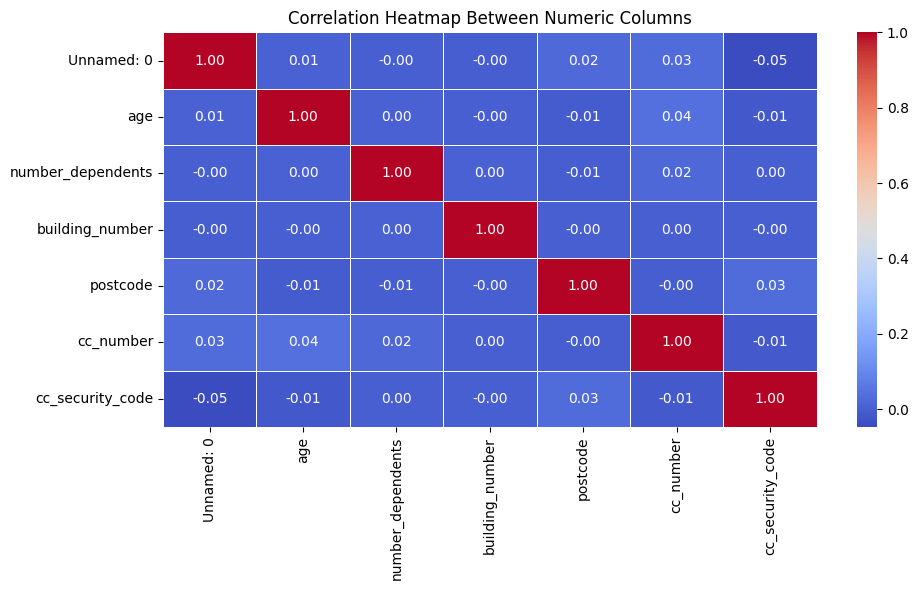

In [27]:
# <Student to fill this section>
# Select only numeric columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation
corr_matrix = numerical_df.corr()

# Plot Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap Between Numeric Columns")
plt.tight_layout()
plt.show()

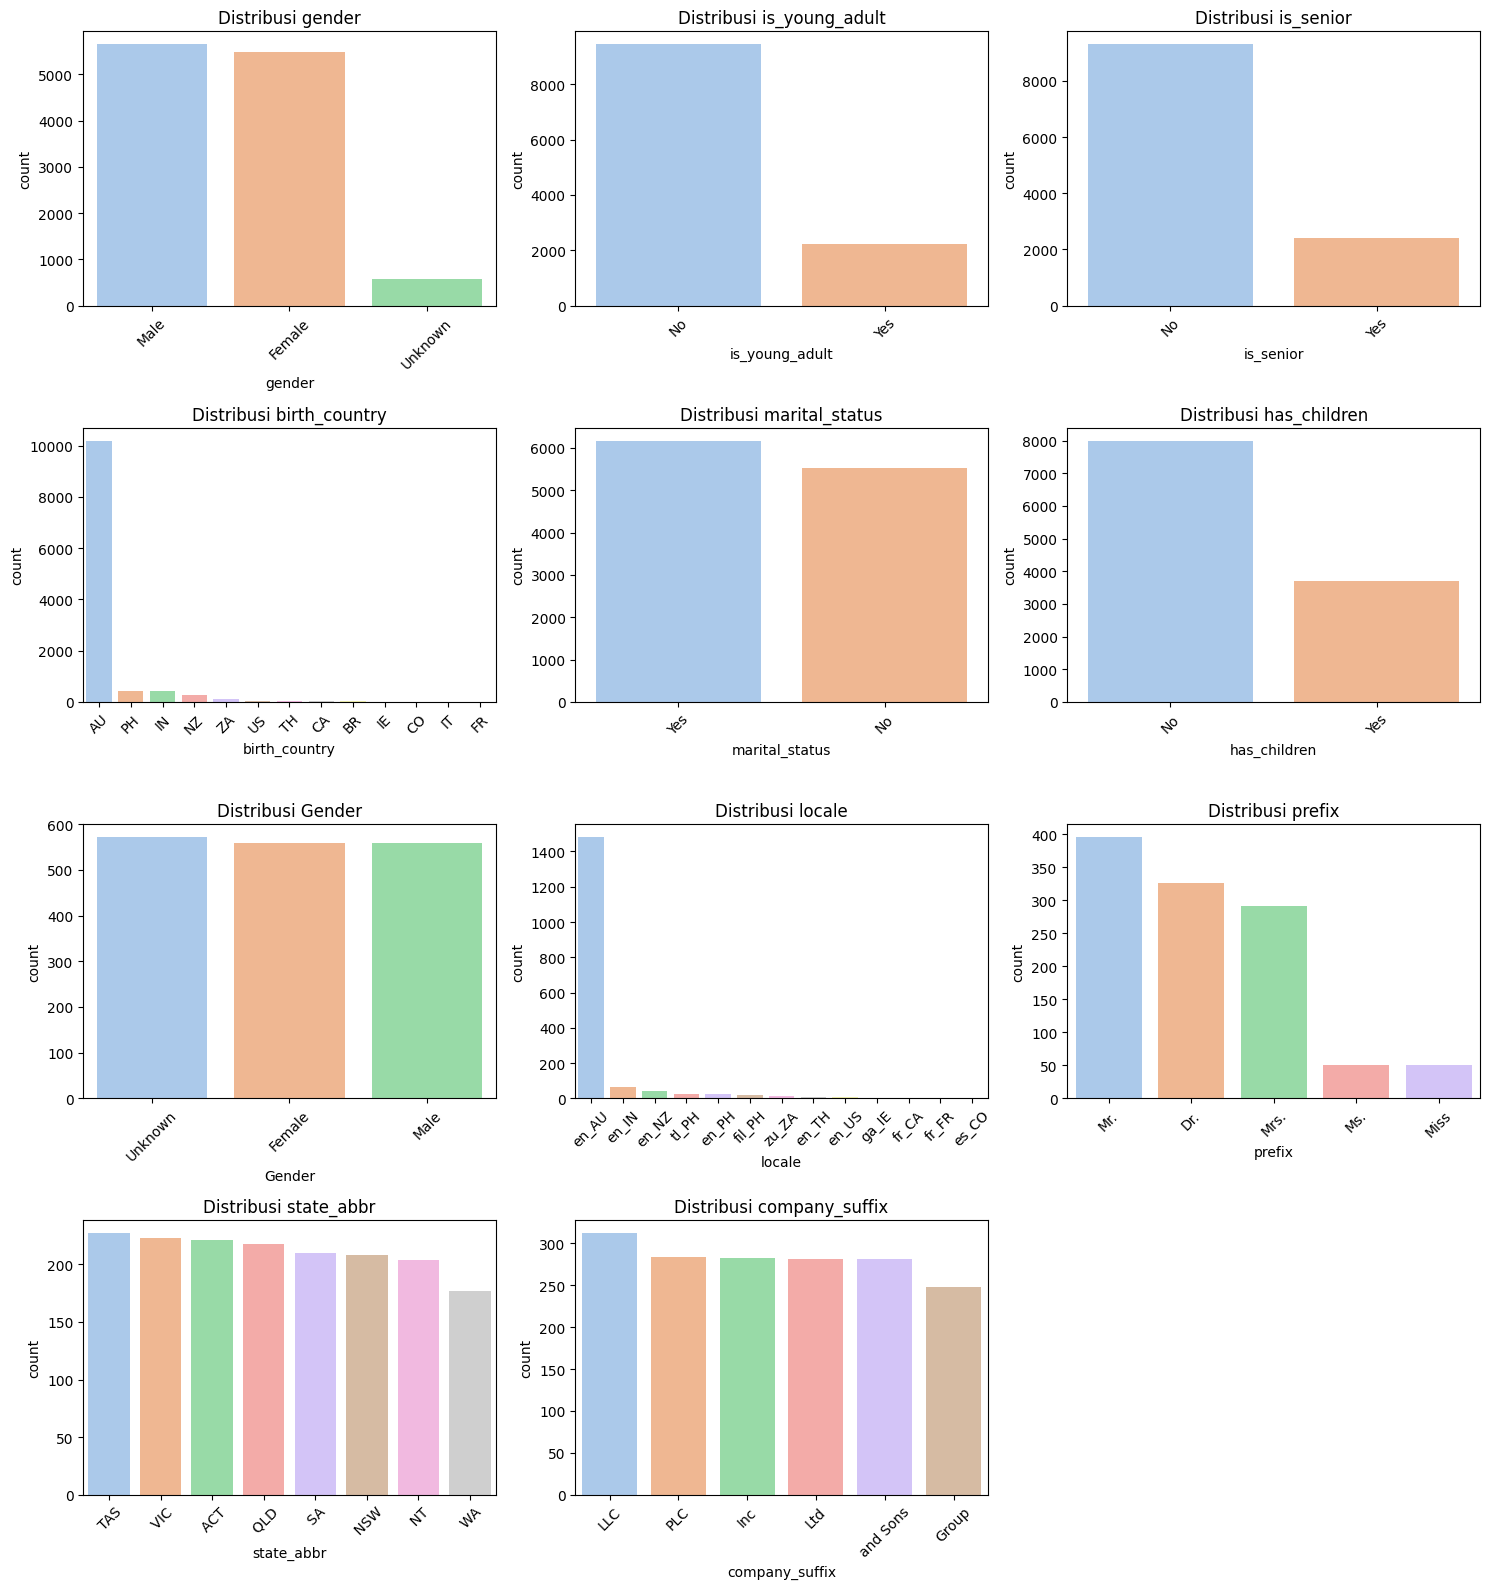

In [28]:
# Automatically identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Filter columns by a reasonable number of uniques to plot (< 30 categories)
categorical_cols = [col for col in categorical_cols if df[col].nunique() < 30]

# Set the number of subplots
n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

# Create a plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

# Plot each column
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='pastel', order=df[col].value_counts().index)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Delete unused axes if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

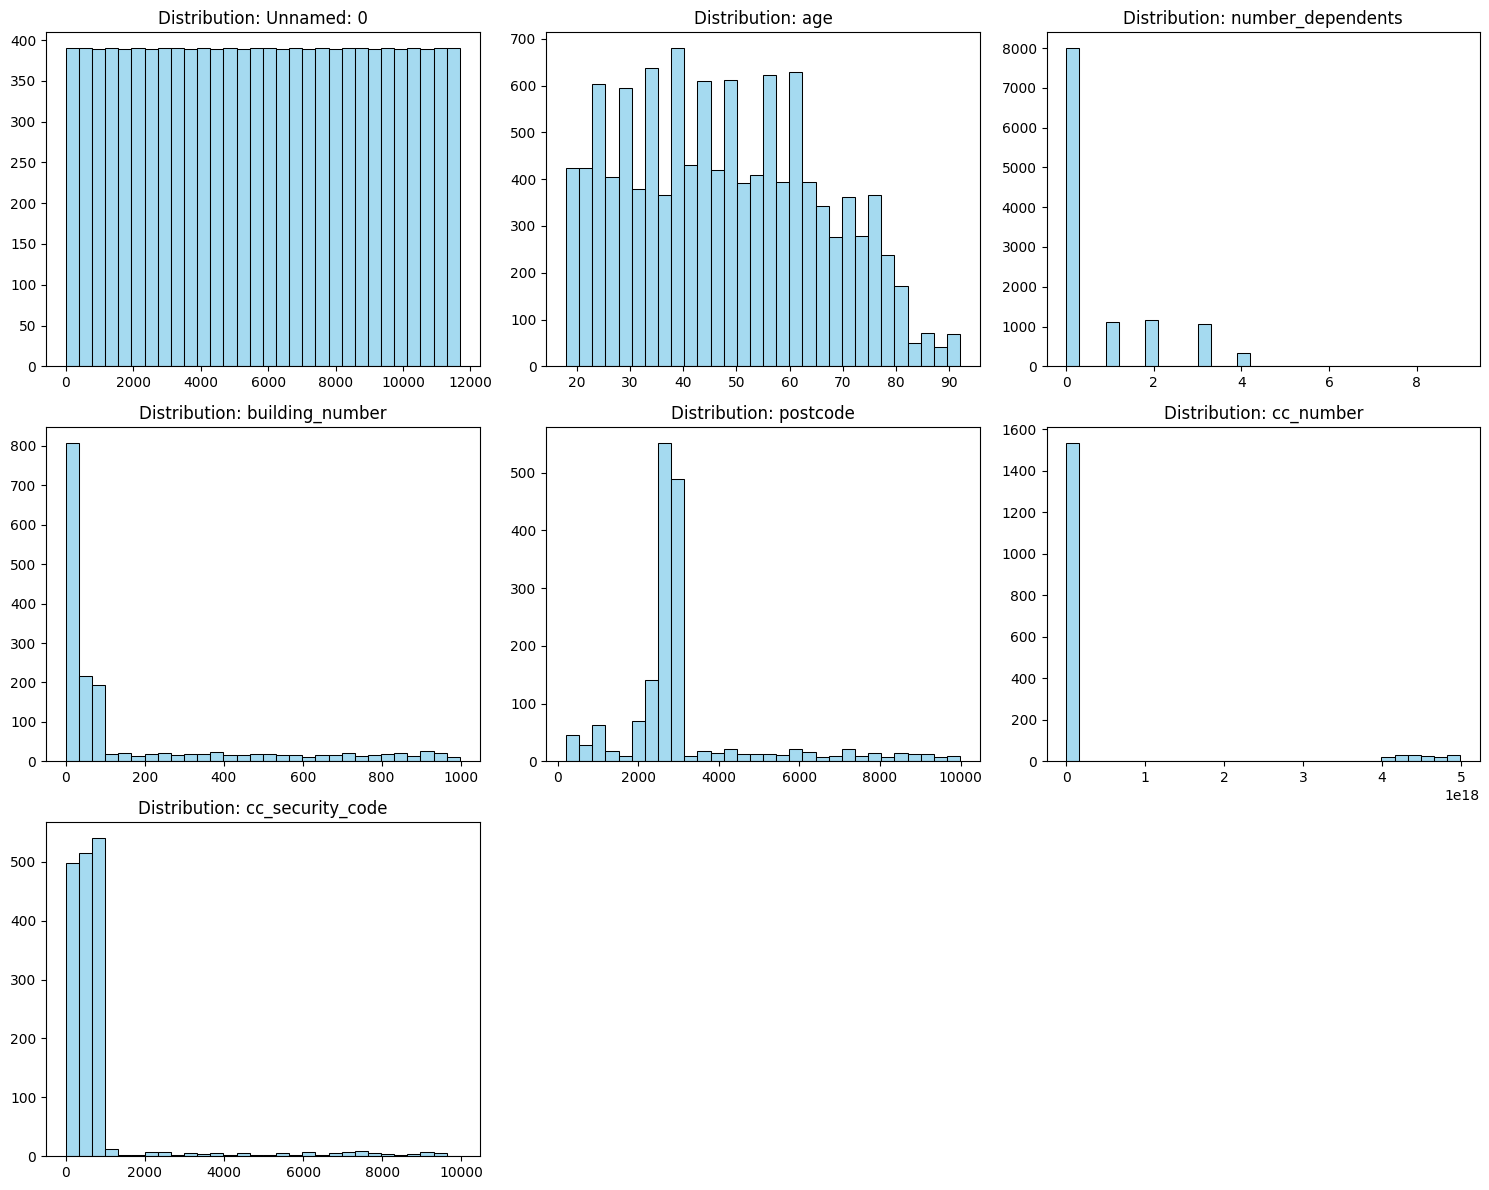

In [29]:
# Take all numeric columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Determine the number of grid rows and columns
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

# Make a plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

# Plot histogram
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, kde=False, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Empty the remaining plot if the number of columns is not divisible by n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [30]:
# <Student to fill this section>
feature_2_insights = """
All correlation values ​​are very close to zero, indicating that there is no strong linear relationship between the numeric features.
The features age, number_dependents, building_number, postcode, cc_number, and cc_security_code are not correlated with each other,
which means they can provide unique information in the model, but can also show high uncorrelation in the context of business and analysis.

Based on the visualization of the distribution of demographic data, the majority of individuals in this dataset are from Australia,
with a nearly balanced gender proportion between men and women, and little unknown data.
Most individuals are neither young adults nor seniors, indicating a dominance of the middle adult age group.
Marital status shows a nearly balanced number between married and unmarried, but the majority do not have children.
This finding provides a picture of a relatively mature population, not too young or old, dominated by local residents, and most do not have children.

Then, it can be concluded that the majority of data uses the en_AU locale, confirming that the population is dominated by users from Australia.
The gender distribution is quite balanced between men, women, and the unknown category.
The most commonly used prefix is ​​"Mr.", followed by "Dr." and "Mrs.", indicating a predominance of male users and formal titles.
The distribution of state distribution in Australia is also quite even, with almost equal representation across states such as TAS, VIC, ACT, to WA.
For business entities, the suffixes "LLC", "PLC", and "Inc" dominate, reflecting a diverse but fairly balanced form of corporate organization.

The data displayed shows a diverse distribution. The age column shows a major concentration at the age of 30–60 years,
reflecting the majority of respondents are in their productive age. Most have no dependents (number_dependents = 0).
The distribution of building_number and postcode is very skewed to the left, indicating a predominance of low values,
while cc_number appears extremely skewed with many small values, likely dummies. The Unnamed: 0 column appears to be a unique ID that is evenly distributed.
Overall, the data is quite clean, although some numeric columns require special attention before being used for further analysis.

"""

In [31]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.5 Explore Feature of Interest n

> You can add more cells in this section

<Axes: >

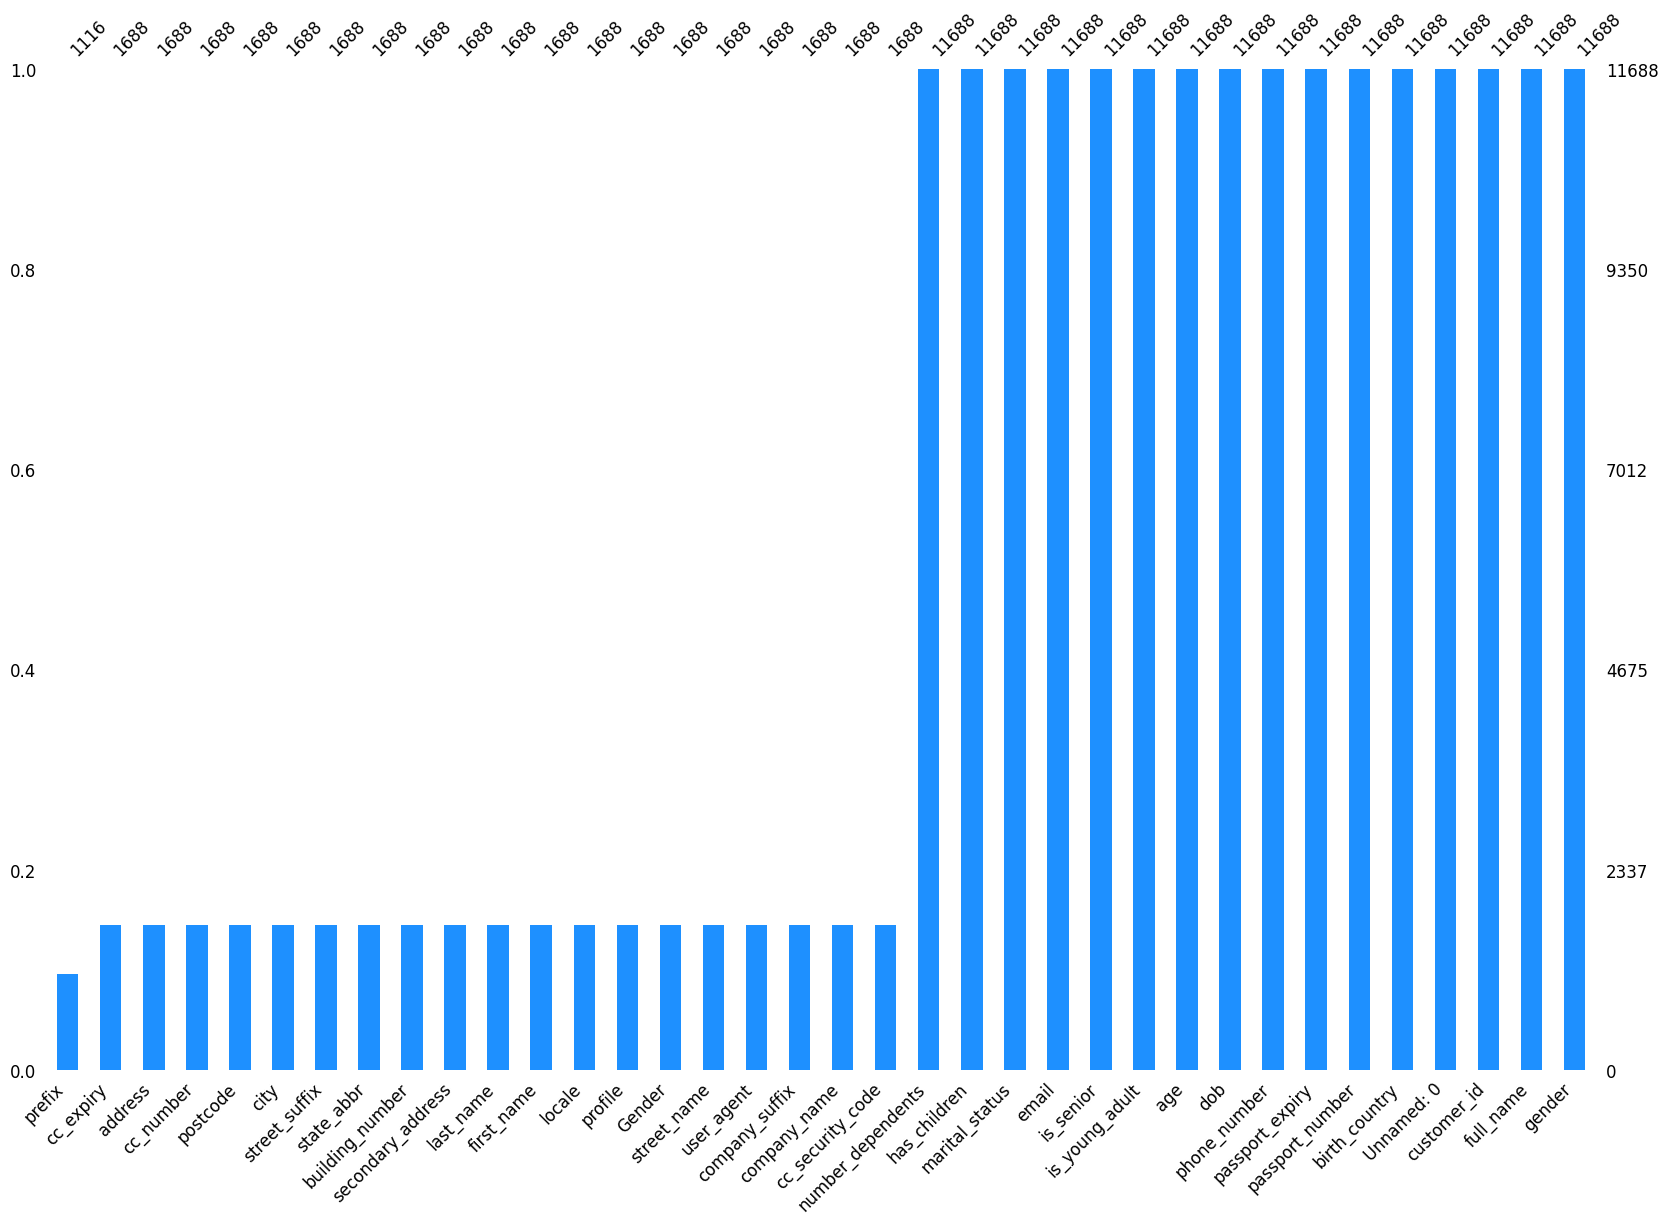

In [32]:
# <Student to fill this section>
missing_pct = df.isnull().mean()

msno.bar(df,
         color="dodgerblue",
         sort="ascending",
         figsize=(20, 13),
         fontsize=12)

<Axes: >

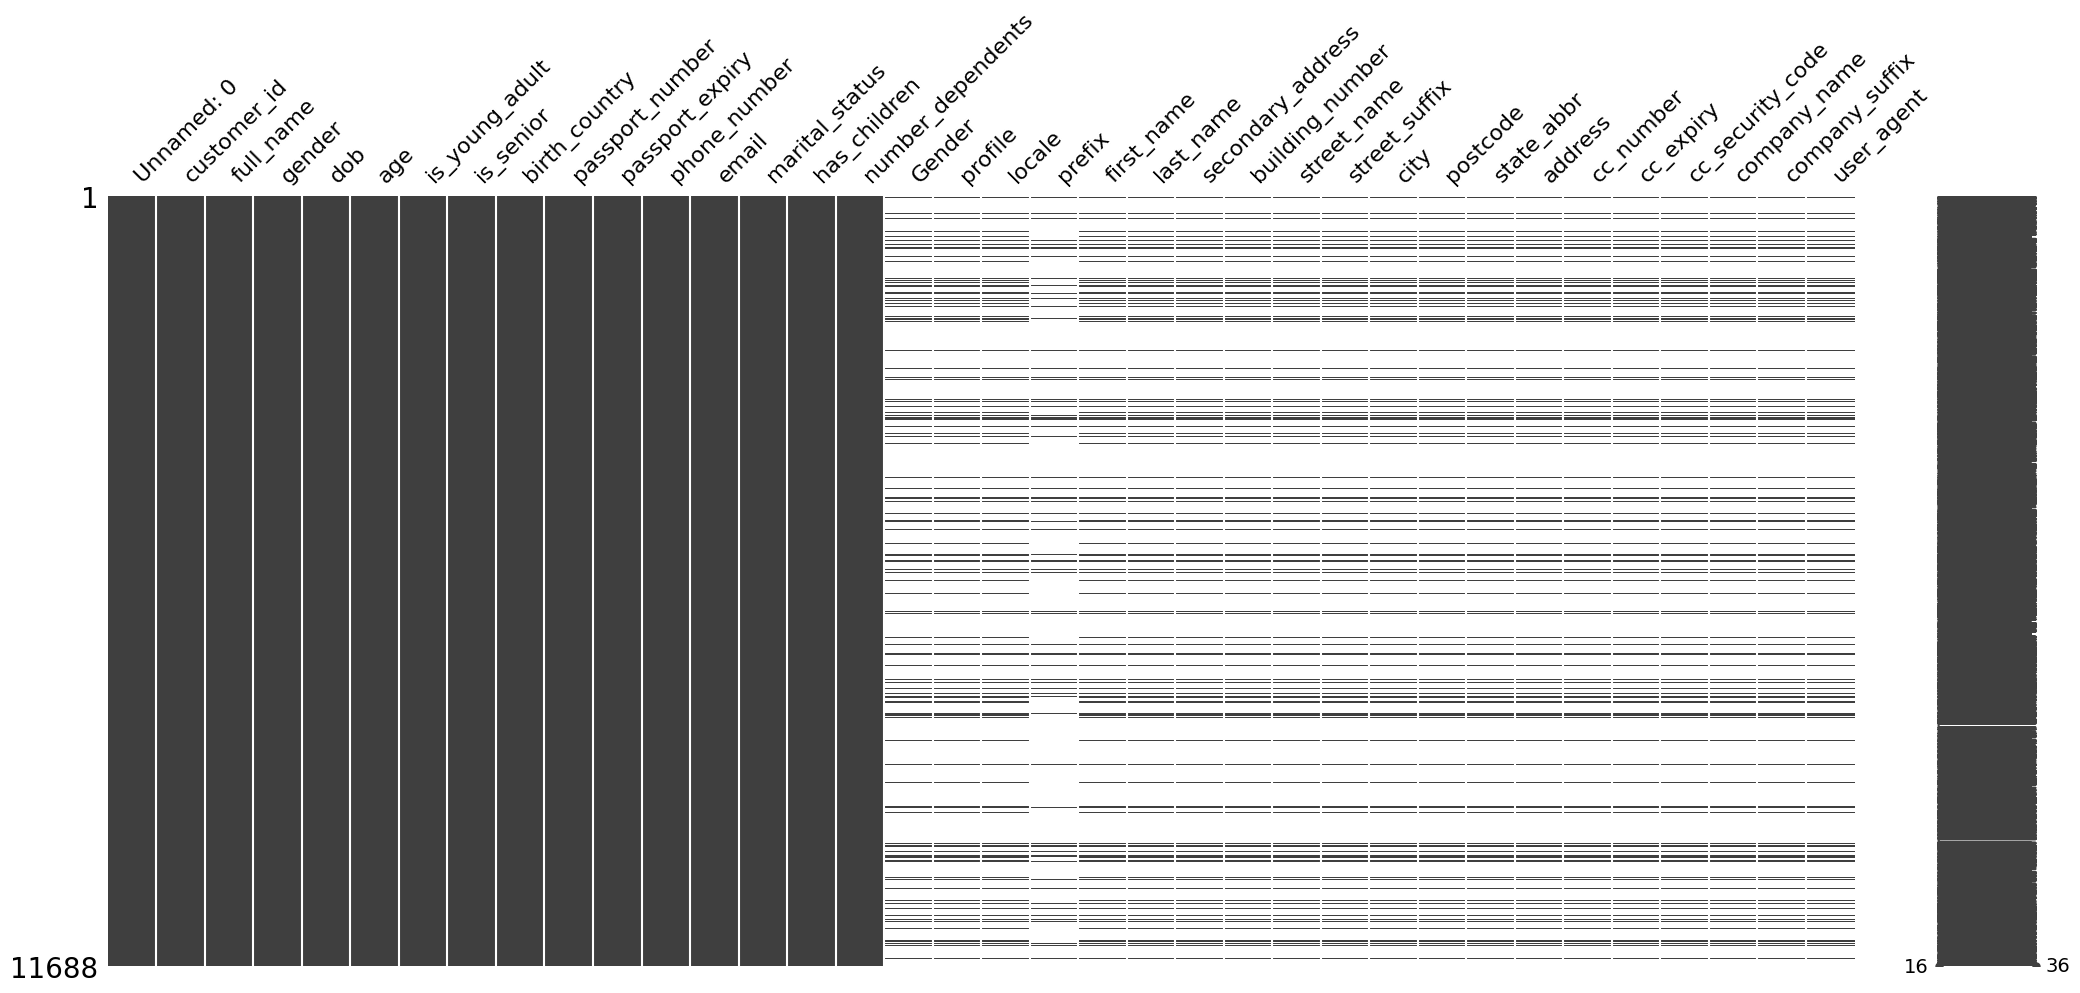

In [33]:
msno.matrix(df)

In [34]:
# <Student to fill this section>
feature_n_insights = """
The missing value visualization above shows that the dataset consists of 11,688 entries and about 36 columns.
Each row represents one data entry, and each column represents a different feature.
The black color indicates that the data is available, while the white color indicates that there is missing data.
Likewise with the first visualization, the blue color indicates data availability.
It can be seen that the columns, such as customer_id, dob, age, and email have complete data.
Then, a number of columns in others, such as profile, prefix, secondary_address, cc_security_code have a significant number of missing values.
This visualization is very helpful in the data cleaning process, because we can easily identify which columns need attention.
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## C. Data Cleaning

### C.1 Copy Dataset

In [65]:
# Do not modify this code
df_clean = df.copy()
try:
  df_clean = df.copy()
except Exception as e:
  print(e)

### C.2 Fixing "\<Duplicates\>"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [66]:
# <Student to fill this section>
df_clean = df_clean.drop(columns=['Unnamed: 0'], errors='ignore')

In [67]:
print("Duplicate at the df:", df_clean.duplicated().sum())

Duplicate at the df: 2957


In [68]:
df_clean = df_clean.drop_duplicates()

In [69]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8731 entries, 0 to 11686
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        8731 non-null   object 
 1   full_name          8731 non-null   object 
 2   gender             8731 non-null   object 
 3   dob                8731 non-null   object 
 4   age                8731 non-null   int64  
 5   is_young_adult     8731 non-null   object 
 6   is_senior          8731 non-null   object 
 7   birth_country      8731 non-null   object 
 8   passport_number    8731 non-null   object 
 9   passport_expiry    8731 non-null   object 
 10  phone_number       8731 non-null   object 
 11  email              8731 non-null   object 
 12  marital_status     8731 non-null   object 
 13  has_children       8731 non-null   object 
 14  number_dependents  8731 non-null   int64  
 15  Gender             1688 non-null   object 
 16  profile            1688 non-

In [70]:
# <Student to fill this section>
data_cleaning_1_explanations = """
The Unnamed: 0 column is removed because it is only an index from the CSV file and does not carry any important information.
After that, duplicate data is removed to ensure each row represents a unique entity and prevent bias or double counting in the analysis.
"""

In [71]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### C.3 Fixing "\<Missing Value\>"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [72]:
# <Student to fill this section>
df_clean.isnull().sum()

,0
customer_id,0
full_name,0
gender,0
dob,0
age,0
is_young_adult,0
is_senior,0
birth_country,0
passport_number,0
passport_expiry,0


In [73]:
cols_to_drop = ['Gender', 'profile', 'locale', 'prefix', 'first_name', 'last_name',
                'secondary_address', 'building_number', 'street_name', 'street_suffix',
                'city', 'postcode', 'state_abbr', 'address', 'cc_number', 'cc_expiry',
                'cc_security_code', 'company_name', 'company_suffix', 'user_agent',
                'phone_number', 'email']

df_clean = df_clean.drop(columns=cols_to_drop)

In [57]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8731 entries, 0 to 11686
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        8731 non-null   object
 1   full_name          8731 non-null   object
 2   gender             8731 non-null   object
 3   dob                8731 non-null   object
 4   age                8731 non-null   int64 
 5   is_young_adult     8731 non-null   object
 6   is_senior          8731 non-null   object
 7   birth_country      8731 non-null   object
 8   passport_number    8731 non-null   object
 9   passport_expiry    8731 non-null   object
 10  phone_number       8731 non-null   object
 11  email              8731 non-null   object
 12  marital_status     8731 non-null   object
 13  has_children       8731 non-null   object
 14  number_dependents  8731 non-null   int64 
dtypes: int64(2), object(13)
memory usage: 1.1+ MB


In [74]:
# <Student to fill this section>
data_cleaning_2_explanations = """
In dealing with missing values, I took an approach with a relevance evaluation on the domain.
The result was that the variables gender, profile, locale, first_name, last_name, address, secondary_address, phone_number, and email were removed
because there were too many missing, biased, and personal information that was not relevant to the project objectives or target variables.
Then, the variables prefix, building_number, street_name, street_suffix, city, postcode, and state_abbr were also removed
because they had low values ​​for the model and were difficult to impute.
After that, the variables cc_number, cc_expiry, and cc_security_code were also removed because they were too sensitive for modeling and not relevant to the target variable.
The variables company_name, company_suffix, and user_agent were removed
because they had many missing values, were not directly relevant to revenue, and their information extraction required additional effort
that was likely not comparable to the added value in revenue prediction.
"""

In [75]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### C.4 Fixing "\<Data Formatting\>"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [76]:
# <Student to fill this section>
df_clean['dob'] = pd.to_datetime(df_clean['dob'], errors='coerce')
df_clean['passport_expiry'] = pd.to_datetime(df_clean['passport_expiry'], errors='coerce')

In [77]:
categorical_cols = ['gender', 'is_young_adult', 'is_senior', 'birth_country',
                    'marital_status', 'has_children']

df_clean[categorical_cols] = df_clean[categorical_cols].astype('category')

In [78]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8731 entries, 0 to 11686
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        8731 non-null   object        
 1   full_name          8731 non-null   object        
 2   gender             8731 non-null   category      
 3   dob                8731 non-null   datetime64[ns]
 4   age                8731 non-null   int64         
 5   is_young_adult     8731 non-null   category      
 6   is_senior          8731 non-null   category      
 7   birth_country      8731 non-null   category      
 8   passport_number    8731 non-null   object        
 9   passport_expiry    8731 non-null   datetime64[ns]
 10  marital_status     8731 non-null   category      
 11  has_children       8731 non-null   category      
 12  number_dependents  8731 non-null   int64         
dtypes: category(6), datetime64[ns](2), int64(2), object(3)
memory usage

In [79]:
df_clean.head()

,customer_id,full_name,gender,dob,age,is_young_adult,is_senior,birth_country,passport_number,passport_expiry,marital_status,has_children,number_dependents
0,9acb3a1e-a040-4280-887b-ef33381c7a16,Alexa Chung,Female,1974-10-10,50,No,No,AU,131053534,2029-11-21,Yes,Yes,2
1,45360147-4c3e-4f3d-8d8d-a6aa8f0bb47f,Mrs. Megan,Female,1981-09-27,43,No,No,AU,379521345,2028-04-11,Yes,No,0
2,8345bdc5-75fd-41da-8ce5-7828e5a27666,Amy Rose,Female,1989-09-16,35,No,No,PH,794022868,2028-12-13,Yes,No,0
3,0ec226b1-22e6-4b98-919f-c1c0cd183ea7,Ryan Peterson,Male,2001-02-03,24,Yes,No,AU,M21113240,2027-05-23,No,No,0
4,f588a5e1-7b36-4db2-af9a-2c14e041fccb,Shelby Meyer,Female,1977-02-11,48,No,No,AU,956682468,2029-10-24,No,No,0


In [80]:
# <Student to fill this section>
data_cleaning_3_explanations = """
I converted the data type in column dob and passport expiry to date format, and changed several text type columns to categories as a form of data formatting.
"""

In [81]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## D. Feature Engineering

### D.1 Copy Datasets

In [90]:
# Do not modify this code
try:
  df_eng = df_clean.copy()
except Exception as e:
  print(e)

### D.2 New Feature "\<Data Enrichment\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [94]:
# <Student to fill this section>
df1 = df1.drop(columns=['Unnamed: 0'], errors='ignore')
print("Duplicate in the df1:", df1.duplicated().sum())

Duplicate in the df1: 4082


In [95]:
df1 = df1.drop_duplicates()
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 11124
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   avg_monthly_international_charges  7043 non-null   float64
 2   avg_monthly_download_in_gb         7043 non-null   int64  
 3   monthly_charge                     7043 non-null   float64
 4   total_charges                      6933 non-null   float64
 5   total_refunds                      6823 non-null   float64
 6   total_extra_data_charges           6933 non-null   float64
 7   total_international_charges        6209 non-null   float64
 8   total_revenue                      5816 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 550.2+ KB


In [96]:
df_eng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8731 entries, 0 to 11686
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        8731 non-null   object        
 1   full_name          8731 non-null   object        
 2   gender             8731 non-null   category      
 3   dob                8731 non-null   datetime64[ns]
 4   age                8731 non-null   int64         
 5   is_young_adult     8731 non-null   category      
 6   is_senior          8731 non-null   category      
 7   birth_country      8731 non-null   category      
 8   passport_number    8731 non-null   object        
 9   passport_expiry    8731 non-null   datetime64[ns]
 10  marital_status     8731 non-null   category      
 11  has_children       8731 non-null   category      
 12  number_dependents  8731 non-null   int64         
dtypes: category(6), datetime64[ns](2), int64(2), object(3)
memory usage

In [97]:
df_eng = df_eng.merge(df1, on='customer_id', how='inner')

In [98]:
df_eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   customer_id                        7043 non-null   object        
 1   full_name                          7043 non-null   object        
 2   gender                             7043 non-null   category      
 3   dob                                7043 non-null   datetime64[ns]
 4   age                                7043 non-null   int64         
 5   is_young_adult                     7043 non-null   category      
 6   is_senior                          7043 non-null   category      
 7   birth_country                      7043 non-null   category      
 8   passport_number                    7043 non-null   object        
 9   passport_expiry                    7043 non-null   datetime64[ns]
 10  marital_status                     7

In [99]:
print("Duplicate in the df_eng:", df_eng.duplicated().sum())

Duplicate in the df_eng: 0


In [100]:
# <Student to fill this section>
feature_engineering_1_explanations = """
In this project, the problem to be solved is to help the Finance Team adjust the budget by predicting next month's revenue.
It should be noted that the revenue variable is not available in the customer detail data.
Therefore, a merger between customer detail data and customer usage is carried out based on customer_id.
After the merger process between df_eng (customer data) and df1 (usage and revenue data), 7,043 rows of customer data were obtained that had complete information,
both in terms of demographics and service usage behavior.
"""

In [101]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### D.3 New Feature "\<refund_ratio and extra_data_ratio\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [102]:
# <Student to fill this section>
df_eng["refund_ratio"] = df_eng["total_refunds"] / df_eng["total_charges"].replace(0, np.nan)
df_eng["extra_data_ratio"] = df_eng["total_extra_data_charges"] / df_eng["total_charges"].replace(0, np.nan)

In [103]:
df_eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   customer_id                        7043 non-null   object        
 1   full_name                          7043 non-null   object        
 2   gender                             7043 non-null   category      
 3   dob                                7043 non-null   datetime64[ns]
 4   age                                7043 non-null   int64         
 5   is_young_adult                     7043 non-null   category      
 6   is_senior                          7043 non-null   category      
 7   birth_country                      7043 non-null   category      
 8   passport_number                    7043 non-null   object        
 9   passport_expiry                    7043 non-null   datetime64[ns]
 10  marital_status                     7

In [104]:
# <Student to fill this section>
feature_engineering_2_explanations = """
In the context of revenue prediction, creating financial ratio features such as refund_ratio and extra_data_ratio is more relevant,
because it is directly related to money, captures customer efficiency or inefficiency, and increases signals to the model.
This means an approach to customer behavior towards revenue, such as whether customers often refund, whether they often use additional quotas,
dissatisfied or often complaining behavior, active customers who have the potential for large revenue, and others.
"""

In [105]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### D.4 New Feature "\<encoding\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [106]:
# <Student to fill this section>
df_eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   customer_id                        7043 non-null   object        
 1   full_name                          7043 non-null   object        
 2   gender                             7043 non-null   category      
 3   dob                                7043 non-null   datetime64[ns]
 4   age                                7043 non-null   int64         
 5   is_young_adult                     7043 non-null   category      
 6   is_senior                          7043 non-null   category      
 7   birth_country                      7043 non-null   category      
 8   passport_number                    7043 non-null   object        
 9   passport_expiry                    7043 non-null   datetime64[ns]
 10  marital_status                     7

In [108]:
def display_unique(df_eng):
  listUniqueItem = []
  for col in df_eng.columns :
      listUniqueItem.append( [col, df_eng[col].nunique(), df_eng[col].isna().sum(), df_eng[col].unique()])

  tableDesc = pd.DataFrame(columns=['Column Name', 'Total of Unique', 'null', 'Unique Sample'],
                      data=listUniqueItem)
  return tableDesc

display_unique(df_eng)

,Column Name,Total of Unique,null,Unique Sample
0,customer_id,7043,0,"[9acb3a1e-a040-4280-887b-ef33381c7a16, 4536014..."
1,full_name,6734,0,"[Alexa Chung, Mrs. Megan, Amy Rose, Ryan Peter..."
2,gender,2,0,"['Female', 'Male'] Categories (3, object): ['F..."
3,dob,6005,0,"[1974-10-10 00:00:00, 1981-09-27 00:00:00, 198..."
4,age,62,0,"[50, 43, 35, 24, 48, 63, 36, 57, 19, 38, 49, 6..."
5,is_young_adult,2,0,"['No', 'Yes'] Categories (2, object): ['No', '..."
6,is_senior,2,0,"['No', 'Yes'] Categories (2, object): ['No', '..."
7,birth_country,13,0,"['AU', 'PH', 'IN', 'CO', 'US', ..., 'ZA', 'FR'..."
8,passport_number,7043,0,"[131053534, 379521345, 794022868, M21113240, 9..."
9,passport_expiry,1737,0,"[2029-11-21 00:00:00, 2028-04-11 00:00:00, 202..."


In [109]:
df_eng["gender"] = df_eng["gender"].map({"Male": 1, "Female": 0})
df_eng["is_young_adult"] = df_eng["is_young_adult"].map({"Yes": 1, "No": 0})
df_eng["is_senior"] = df_eng["is_senior"].map({"Yes": 1, "No": 0})
df_eng["has_children"] = df_eng["has_children"].map({"Yes": 1, "No": 0})
df_eng["marital_status"] = df_eng["marital_status"].map({"Yes": 1, "No": 0})

In [110]:
df_eng = pd.get_dummies(df_eng, columns=["birth_country"], drop_first=True)

In [112]:
def display_unique(df_eng):
  listUniqueItem = []
  for col in df_eng.columns :
      listUniqueItem.append( [col, df_eng[col].nunique(), df_eng[col].isna().sum(), df_eng[col].unique()])

  tableDesc = pd.DataFrame(columns=['Column Name', 'Total of Unique', 'null', 'Unique Sample'],
                      data=listUniqueItem)
  return tableDesc

display_unique(df_eng)

,Column Name,Total of Unique,null,Unique Sample
0,customer_id,7043,0,"[9acb3a1e-a040-4280-887b-ef33381c7a16, 4536014..."
1,full_name,6734,0,"[Alexa Chung, Mrs. Megan, Amy Rose, Ryan Peter..."
2,gender,2,0,"[0.0, 1.0]"
3,dob,6005,0,"[1974-10-10 00:00:00, 1981-09-27 00:00:00, 198..."
4,age,62,0,"[50, 43, 35, 24, 48, 63, 36, 57, 19, 38, 49, 6..."
5,is_young_adult,2,0,"[0, 1] Categories (2, int64): [0, 1]"
6,is_senior,2,0,"[0, 1] Categories (2, int64): [0, 1]"
7,passport_number,7043,0,"[131053534, 379521345, 794022868, M21113240, 9..."
8,passport_expiry,1737,0,"[2029-11-21 00:00:00, 2028-04-11 00:00:00, 202..."
9,marital_status,2,0,"[1, 0] Categories (2, int64): [0, 1]"


In [113]:
# <Student to fill this section>
feature_engineering_3_explanations = """
The third feature engineering step is encoding to change categorical features into numeric format so that they can be used in the machine learning modeling process.
Several categorical columns such as gender, is_young_adult, is_senior, marital_status, and has_children have been changed into binary format, namely 0 and 1.
Meanwhile, the birth_country feature which has more than two categories has been changed using the one-hot encoding technique.
As a result, this feature is represented in the form of several dummy columns.
"""

In [114]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

---
## E. Save Datasets

In [115]:
# <Student to fill this section>
df_eng.to_csv('df_RegMod.csv', index=False)

In [116]:
import os
print(os.getcwd())

/content/gdrive/MyDrive/36106/assignment/AT3/data
